In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("student_placement_data.csv")
df

,StudentID,Name,Department,CGPA,Internship,Placed,Company,Package(LPA)
0,1,Amit,CSE,8.2,Yes,Yes,TCS,4.0
1,2,Riya,IT,9.1,Yes,Yes,Infosys,5.0
2,3,Kunal,ME,6.5,No,No,NaN,0.0
3,4,Neha,ECE,7.8,Yes,Yes,Wipro,4.5
4,5,Rahul,CSE,6.2,No,No,NaN,0.0
5,6,Priya,IT,8.7,Yes,Yes,Accenture,6.0
6,7,Ankit,ME,7.0,No,No,NaN,0.0
7,8,Sneha,ECE,8.9,Yes,Yes,Amazon,10.0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   StudentID     8 non-null      int64  
 1   Name          8 non-null      object 
 2   Department    8 non-null      object 
 3   CGPA          8 non-null      float64
 4   Internship    8 non-null      object 
 5   Placed        8 non-null      object 
 6   Company       5 non-null      object 
 7   Package(LPA)  8 non-null      float64
dtypes: float64(2), int64(1), object(5)
memory usage: 644.0+ bytes


,StudentID,CGPA,Package(LPA)
count,8.00000,8.000000,8.000000
mean,4.50000,7.800000,3.687500
std,2.44949,1.118673,3.555052
min,1.00000,6.200000,0.000000
25%,2.75000,6.875000,0.000000
50%,4.50000,8.000000,4.250000
75%,6.25000,8.750000,5.250000
max,8.00000,9.100000,10.000000


In [ ]:
df["Company"] = df["Company"].fillna("Not Placed")

In [ ]:
placed_count = df[df["Placed"] == "Yes"].shape[0]
total_students = df.shape[0]
placement_percentage = (placed_count / total_students) * 100
print("Total Students:", total_students)
print("Placed Students:", placed_count)
print("Placement Percentage:", placement_percentage)

Total Students: 8
Placed Students: 5
Placement Percentage: 62.5


In [ ]:
dept_placement = df.groupby("Department")["Placed"].value_counts().unstack()
dept_placement

Placed,No,Yes
Department,,
CSE,1.0,1.0
ECE,NaN,2.0
IT,NaN,2.0
ME,2.0,NaN


In [ ]:
avg_cgpa_placed = df[df["Placed"] == "Yes"]["CGPA"].mean()
avg_cgpa_not_placed = df[df["Placed"] == "No"]["CGPA"].mean()
print("Average CGPA (Placed):", avg_cgpa_placed)
print("Average CGPA (Not Placed):", avg_cgpa_not_placed)

Average CGPA (Placed): 8.54
Average CGPA (Not Placed): 6.566666666666666


In [ ]:
internship_analysis = df.groupby("Internship")["Placed"].value_counts().unstack()
internship_analysis

Placed,No,Yes
Internship,,
No,3.0,NaN
Yes,NaN,5.0


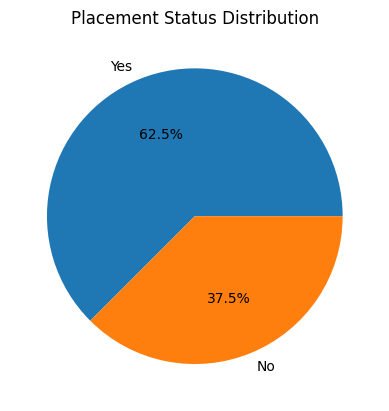

In [ ]:
df["Placed"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Placement Status Distribution")
plt.ylabel("")
plt.show()

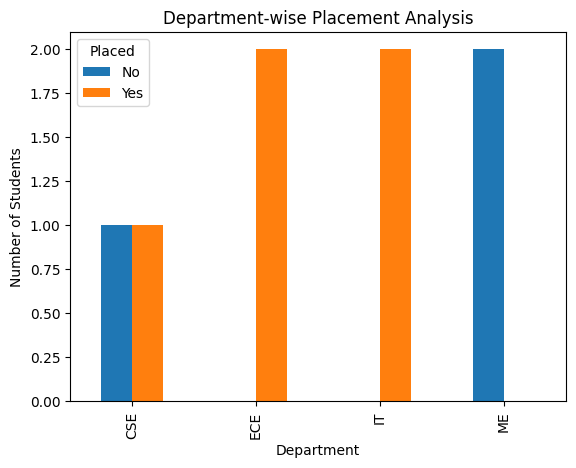

In [ ]:
dept_placement.plot(kind="bar")
plt.title("Department-wise Placement Analysis")
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.show()

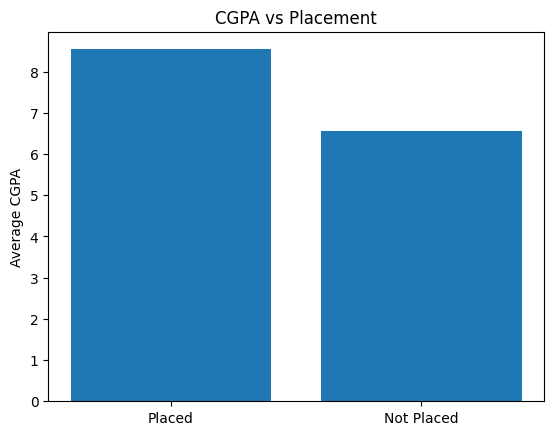

In [ ]:
plt.bar(["Placed", "Not Placed"], [avg_cgpa_placed, avg_cgpa_not_placed])
plt.title("CGPA vs Placement")
plt.ylabel("Average CGPA")
plt.show()

In [ ]:
df.to_csv("placement_analysis_report.csv", index=False)